# Titanic Dataset - Data Cleaning and Exploratory Data Analysis (EDA)

## Objective
The objective of this project is to perform data cleaning and exploratory data analysis (EDA) on the Titanic dataset. The analysis aims to identify patterns, trends, relationships between features, and gain insights into passenger survival.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


##Statistical Summary

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## DATA CLEANING

In [6]:

df["Age"] = df["Age"].fillna(df["Age"].median())


df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column because it has many missing values
df.drop("Cabin", axis=1, inplace=True)

print("Missing Values After Cleaning")
df.isnull().sum()

Missing Values After Cleaning


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Exploratory Data Analysis (EDA)

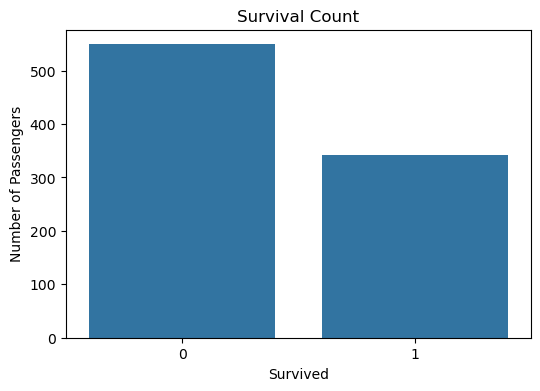

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

**Observation:**
- More passengers died than survived.

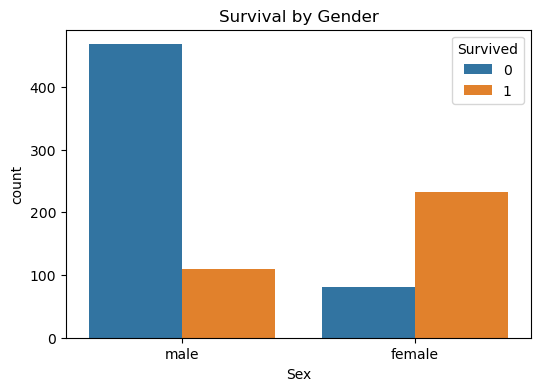

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

**Observation:**
- Female passengers had a much higher survival rate than male passengers.

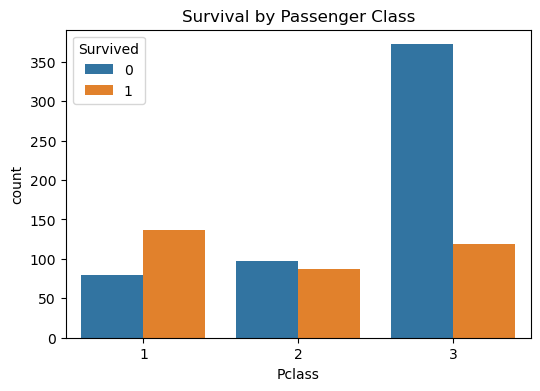

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

**Observation:**
- First-class passengers had the highest survival rate.
- Third-class passengers had the lowest survival rate.

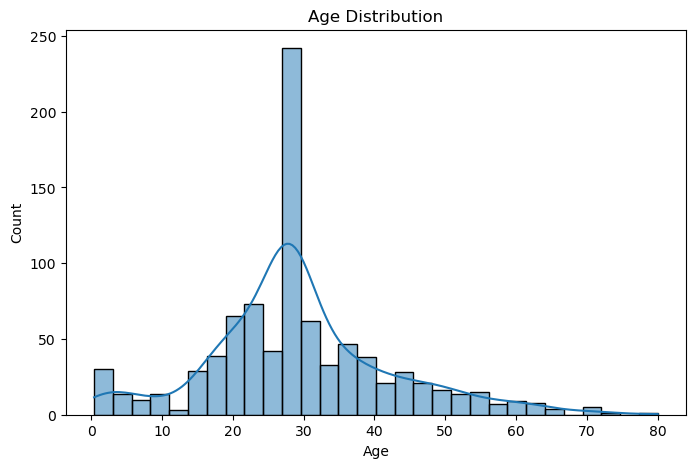

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

**Observation:**
- Most passengers were between 20 and 40 years old.

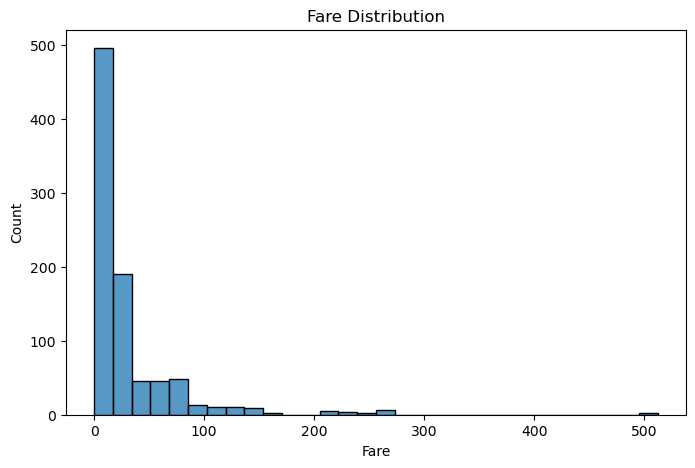

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.show()

**Observation:**
- Most passengers paid relatively low ticket fares.

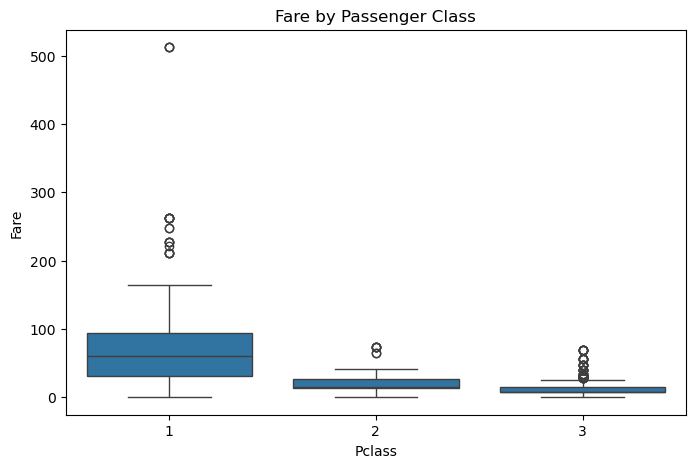

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.title("Fare by Passenger Class")
plt.show()

**Observation:**
- First-class passengers generally paid significantly higher fares.

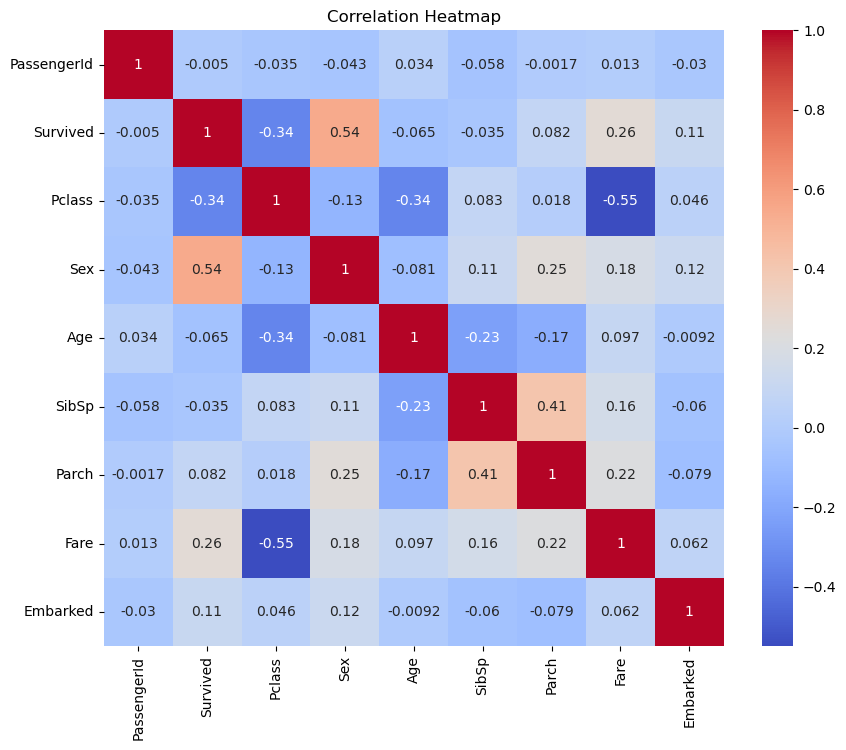

In [13]:
# Create a copy for correlation
corr_df = df.copy()

corr_df["Sex"] = corr_df["Sex"].map({"male":0,"female":1})
corr_df["Embarked"] = corr_df["Embarked"].map({"S":0,"C":1,"Q":2})

plt.figure(figsize=(10,8))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:**
- Gender, passenger class, and fare show noticeable relationships with survival.

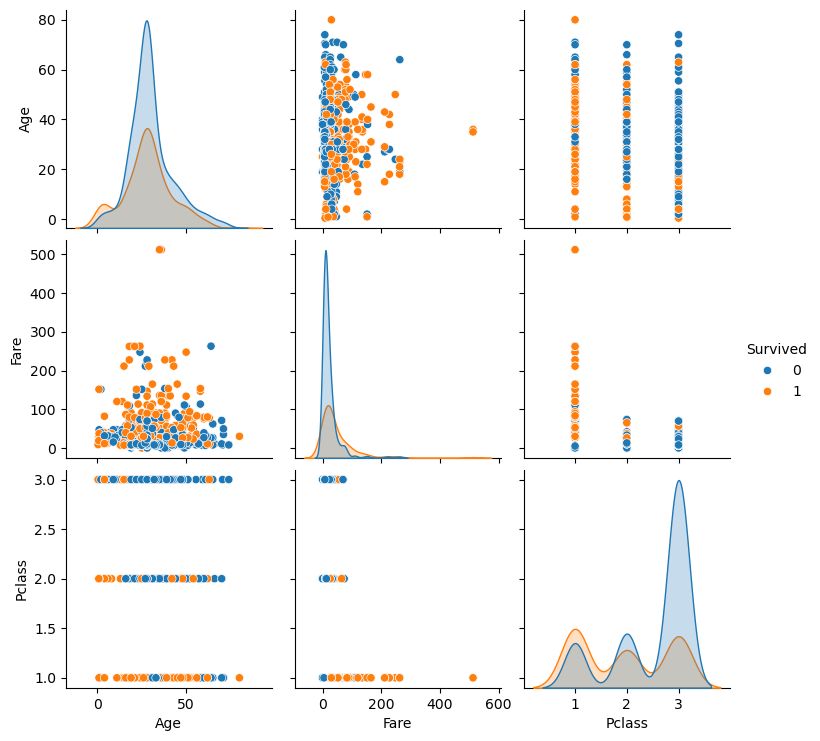

In [14]:
sns.pairplot(corr_df[["Age","Fare","Pclass","Survived"]], hue="Survived")
plt.show()

**Observation:**
- Higher fare and lower passenger class values are associated with better survival chances.